<center><font size=6>Artificial Intelligence and Machine Learning</font></center>
<center><font size=5>Model Deployment - Practice Project</font></center>

<center><font size=6>ExtraaLearn - Potential Customer (Lead) Conversion Prediction</font></center>


# Problem Statement

## Business Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market will be worth **\$286.62bn by 2023** with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as **leads**. There are various sources of obtaining leads for EdTech companies, such as:

- The customer interacts with the marketing front on social media or other online platforms.
- The customer browses the website/app and downloads the brochure.
- The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.


## Objective

**ExtraaLearn** is an initial-stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. As a data scientist at ExtraaLearn, we have been provided the leads data to:

1. Analyze and build an ML model to help identify which leads are more likely to convert to paid customers.
2. Find the factors driving the lead conversion process.
3. Create a profile of the leads which are likely to convert.

> **Note:** This project mirrors the structure of the *Boston House Prediction* solution notebook, but the ExtraaLearn task is a **binary classification** problem (predict `status`: 1 = converted, 0 = not converted). The metrics, models and preprocessing are adapted accordingly, and the model is packaged for deployment (Flask backend + Streamlit frontend, containerized with Docker for a Hugging Face Space).


## Data Dictionary

- **ID**: ID of the lead.
- **age**: Age of the lead.
- **current_occupation**: Current occupation of the lead. Values: 'Professional', 'Unemployed', 'Student'.
- **first_interaction**: How the lead first interacted with ExtraaLearn. Values: 'Website', 'Mobile App'.
- **profile_completed**: Percentage of profile filled. Values: Low (0-50%), Medium (50-75%), High (75-100%).
- **website_visits**: Number of times the lead visited the website.
- **time_spent_on_website**: Total time spent on the website (seconds).
- **page_views_per_visit**: Average number of pages viewed per visit.
- **last_activity**: Last interaction between the lead and ExtraaLearn ('Email Activity', 'Phone Activity', 'Website Activity').
- **print_media_type1**: Whether the lead saw the ad in the Newspaper (Yes/No).
- **print_media_type2**: Whether the lead saw the ad in the Magazine (Yes/No).
- **digital_media**: Whether the lead saw the ad on digital platforms (Yes/No).
- **educational_channels**: Whether the lead heard about ExtraaLearn via education channels (Yes/No).
- **referral**: Whether the lead heard about ExtraaLearn through a reference (Yes/No).
- **status**: Whether the lead was converted to a paid customer (target variable).


# Installing and Importing Necessary Libraries

In [ ]:
!pip install pandas==2.2.2 numpy==2.0.2 scikit-learn==1.6.1 xgboost==2.1.4 joblib==1.4.2 streamlit==1.43.2 flask==3.0.3 -q

In [2]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd
import sklearn

# Data splitting and tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# Data preprocessing and pipeline creation
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Tree-based and ensemble classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from xgboost import XGBClassifier

# Metrics (classification)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Model serialization
import joblib

# File and OS operations
import os

# Pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Reproducibility
RANDOM_STATE = 42

In [3]:
# Set scikit-learn's display mode to 'diagram' for better visualization of pipelines and estimators
sklearn.set_config(display='diagram')

# Data Loading and Overview

On Google Colab, upload `ExtraaLearn.csv` (e.g. via the Files pane or `files.upload()`) so it sits next to the notebook, then run the cell below.

In [4]:
# Loading the dataset
learn_data = pd.read_csv('ExtraaLearn.csv')

# Create a copy of the dataframe so the raw data stays untouched
df = learn_data.copy()

In [5]:
# Display the first five rows of the dataset
df.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [6]:
# Display the number of rows and columns in the dataset
df.shape

(4612, 15)

In [7]:
# Display the column names of the dataset
df.columns

Index(['ID', 'age', 'current_occupation', 'first_interaction',
       'profile_completed', 'website_visits', 'time_spent_on_website',
       'page_views_per_visit', 'last_activity', 'print_media_type1',
       'print_media_type2', 'digital_media', 'educational_channels',
       'referral', 'status'],
      dtype='object')

In [8]:
# Structure of the dataset: data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

In [9]:
# Check for missing values in each column
df.isnull().sum()

ID                       0
age                      0
current_occupation       0
first_interaction        0
profile_completed        0
website_visits           0
time_spent_on_website    0
page_views_per_visit     0
last_activity            0
print_media_type1        0
print_media_type2        0
digital_media            0
educational_channels     0
referral                 0
status                   0
dtype: int64

In [10]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

**Observations**

- The dataset has **4612 rows** and **15 columns**.
- There are **no missing values** and **no duplicate rows**.
- `age`, `website_visits`, `time_spent_on_website`, `page_views_per_visit` are numeric; the rest (except `ID`) are categorical/binary.
- `status` is the target variable.


In [11]:
# The ID column is a unique identifier and carries no predictive signal -> drop it.
df = df.drop(columns=['ID'])
df.head()

,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [12]:
# Statistical summary of numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


In [13]:
# Statistical summary of categorical features
df.describe(include='object').T

,count,unique,top,freq
current_occupation,4612,3,Professional,2616
first_interaction,4612,2,Website,2542
profile_completed,4612,3,High,2264
last_activity,4612,3,Email Activity,2278
print_media_type1,4612,2,No,4115
print_media_type2,4612,2,No,4379
digital_media,4612,2,No,4085
educational_channels,4612,2,No,3907
referral,4612,2,No,4519


**Observations from the statistical summary**

- **age**: ranges from 18 to 63 with a mean of ~46; leads skew towards middle-aged/older adults.
- **website_visits**: mean ~3.6 with a max of 30 -> right-skewed with some highly active visitors.
- **time_spent_on_website**: mean ~724 seconds but a wide spread (0 to 2537) -> strong right skew.
- **page_views_per_visit**: mean ~3 with a max of ~18 -> right-skewed with a few high-engagement leads.
- **current_occupation**: most leads are Professionals.
- **first_interaction**: fairly split between Website and Mobile App.
- Marketing-flag columns (`print_media_type1/2`, `digital_media`, `educational_channels`, `referral`) are dominated by 'No'.


# Exploratory Data Analysis (EDA)

In [14]:
# Define the target variable
target = 'status'

# Define numeric and categorical predictors
numeric_features = df.drop(columns=[target]).select_dtypes(include=np.number).columns.tolist()
categorical_features = df.drop(columns=[target]).select_dtypes(exclude=np.number).columns.tolist()

print(f"Numerical features  : {numeric_features}")
print(f"Categorical features: {categorical_features}")

Numerical features  : ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit']
Categorical features: ['current_occupation', 'first_interaction', 'profile_completed', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']


## Target Variable Distribution

In [15]:
# Proportion of each class in the target variable
df[target].value_counts(normalize=True)

status
0    0.701431
1    0.298569
Name: proportion, dtype: float64

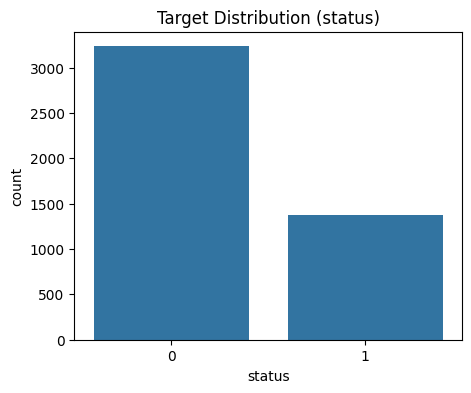

In [16]:
plt.figure(figsize=(5, 4))
sns.countplot(x=target, data=df)
plt.title("Target Distribution (status)")
plt.show()

**Observation:** About **30%** of the leads convert and **70%** do not. This is a **mildly imbalanced** classification problem, which we keep in mind when choosing our evaluation metric.

## Univariate Analysis

### Numerical Features (histogram + boxplot)

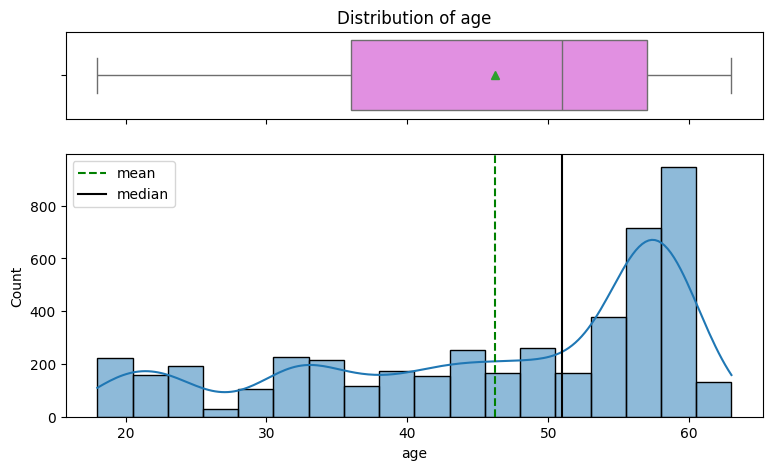

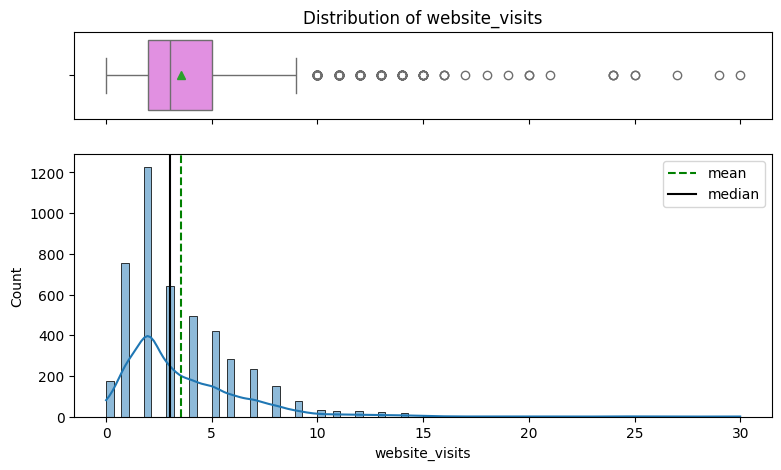

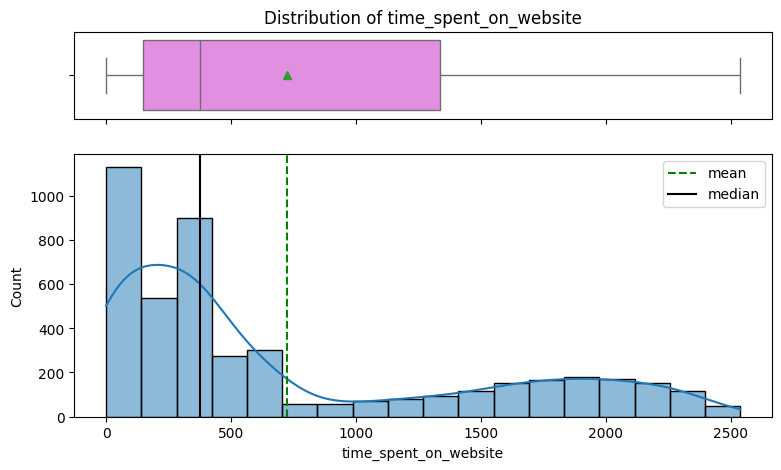

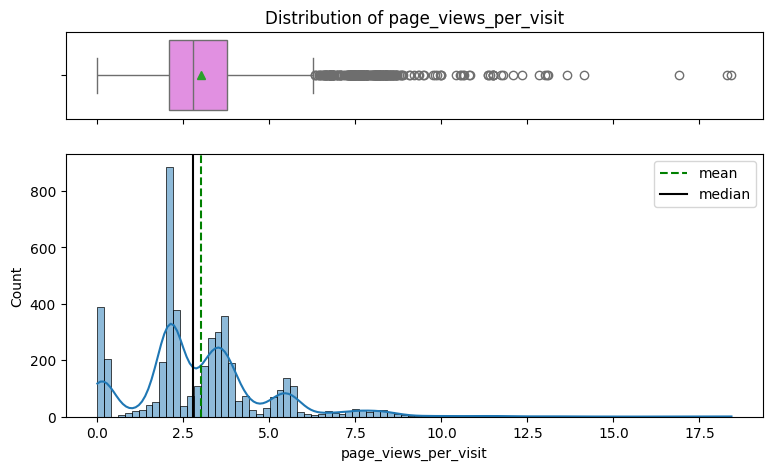

In [17]:
def histogram_boxplot(data, feature, figsize=(9, 5), bins="auto"):
    """Boxplot (top) + histogram (bottom) for a numeric feature."""
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2, sharex=True, figsize=figsize,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
    )
    sns.boxplot(x=data[feature], ax=ax_box, showmeans=True, color="violet")
    sns.histplot(data=data, x=feature, ax=ax_hist, bins=bins, kde=True)
    ax_hist.axvline(data[feature].mean(), color="green", linestyle="--", label="mean")
    ax_hist.axvline(data[feature].median(), color="black", linestyle="-", label="median")
    ax_hist.legend()
    ax_box.set(title=f"Distribution of {feature}")
    plt.show()

for col in numeric_features:
    histogram_boxplot(df, col)

**Observations:** `website_visits`, `time_spent_on_website`, and `page_views_per_visit` are **right-skewed** and contain outliers (highly engaged leads). `age` is roughly symmetric and slightly left-skewed toward older ages.

### Categorical Features (count plots)

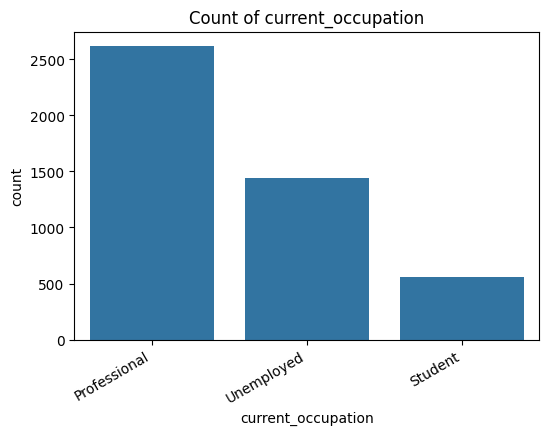

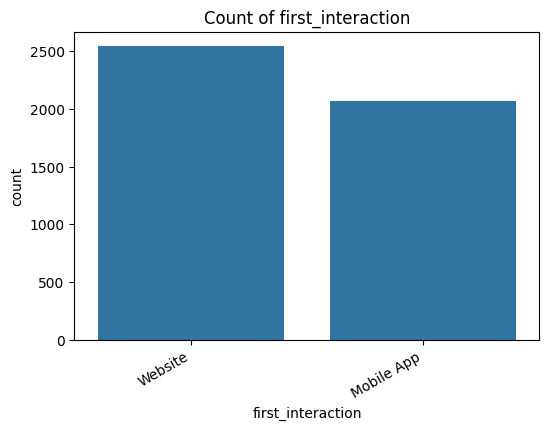

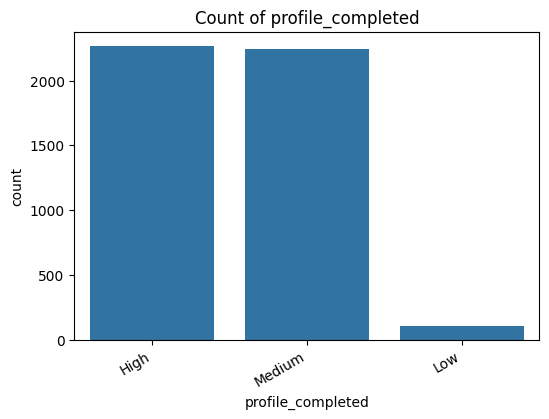

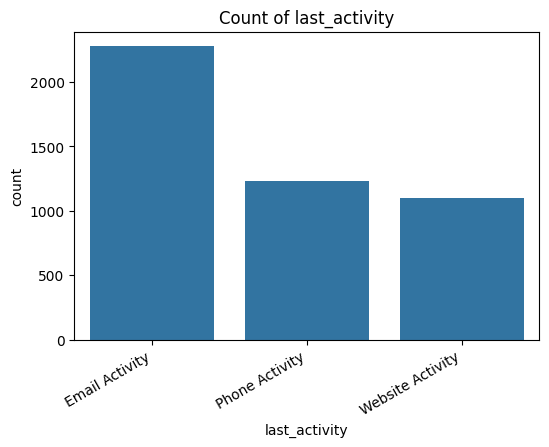

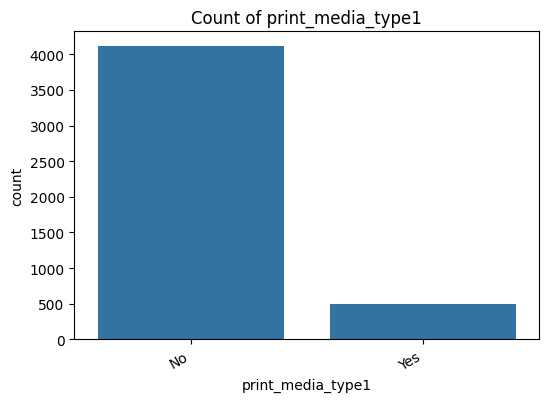

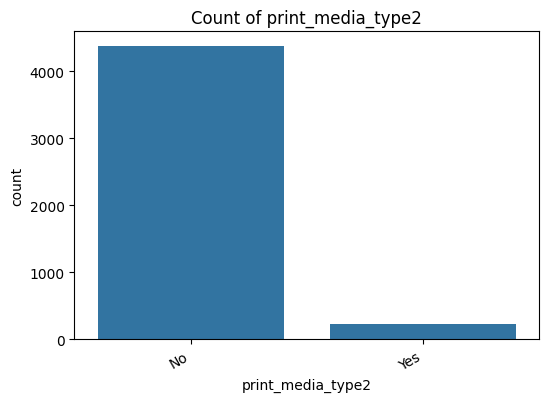

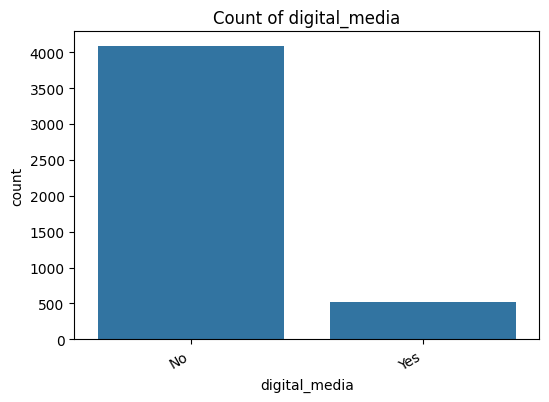

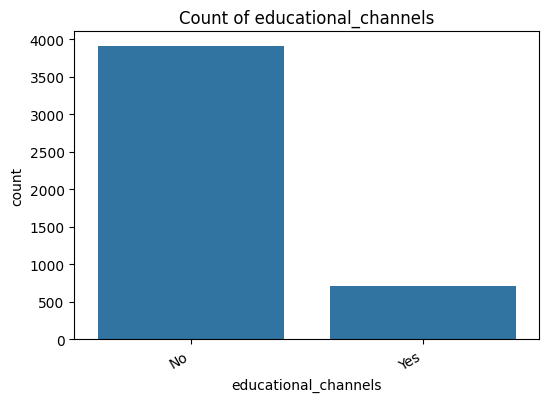

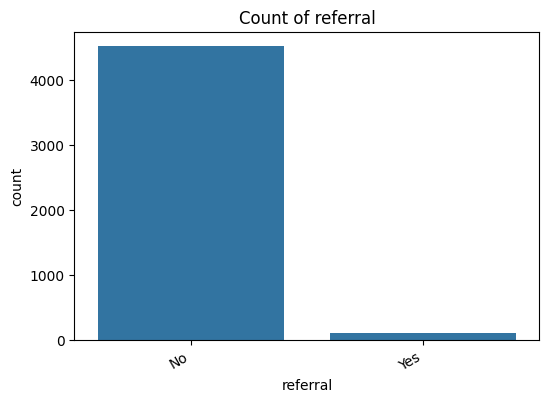

In [18]:
for col in categorical_features:
    plt.figure(figsize=(6, 4))
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=30, ha="right")
    plt.show()

## Bivariate Analysis

### Numerical Features vs Target

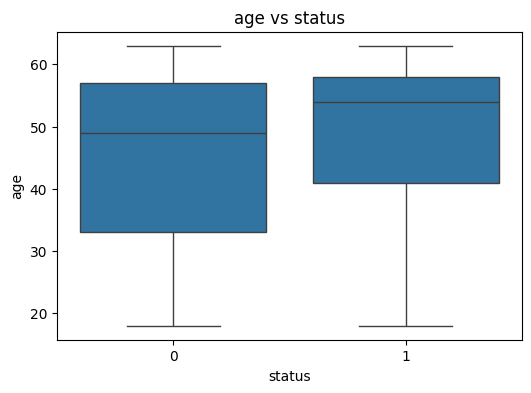

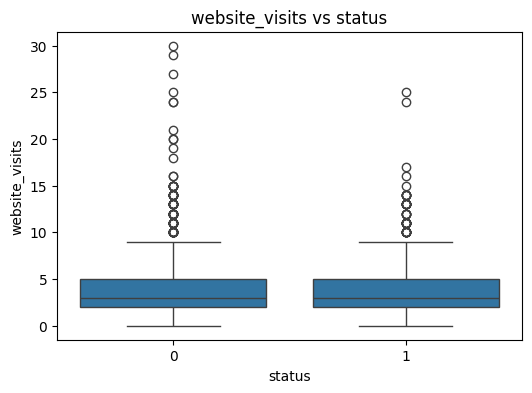

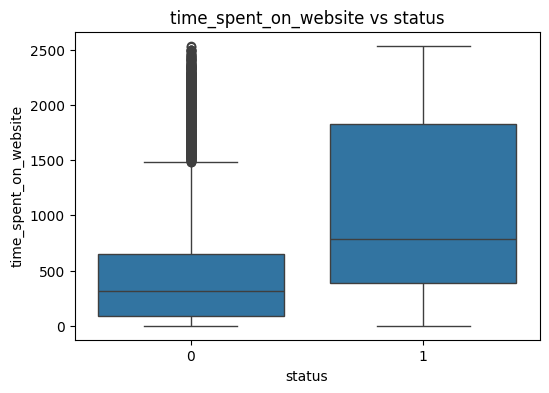

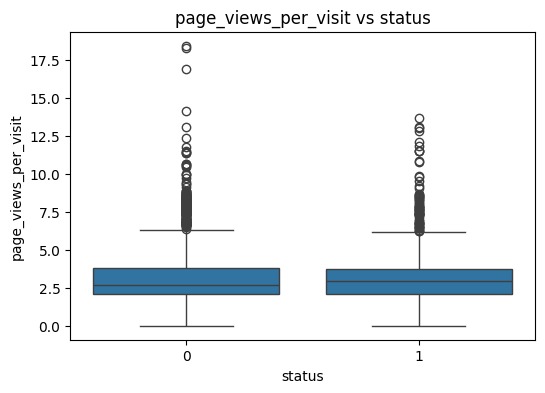

In [19]:
for col in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f"{col} vs {target}")
    plt.show()

**Observation:** Converted leads (status = 1) clearly spend **more time on the website** than non-converted leads. Differences in `age`, `website_visits`, and `page_views_per_visit` between the two classes are comparatively smaller.

### Categorical Features vs Target (stacked proportion)

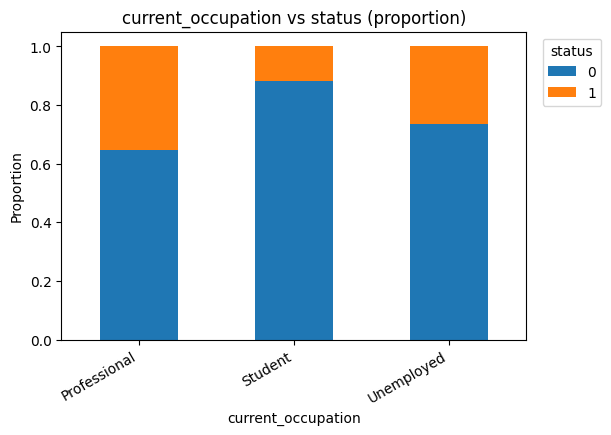

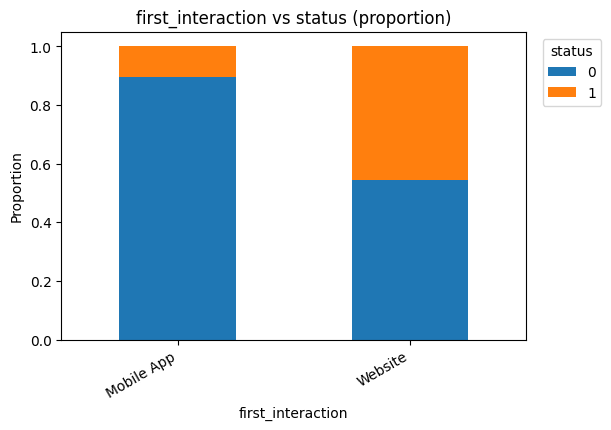

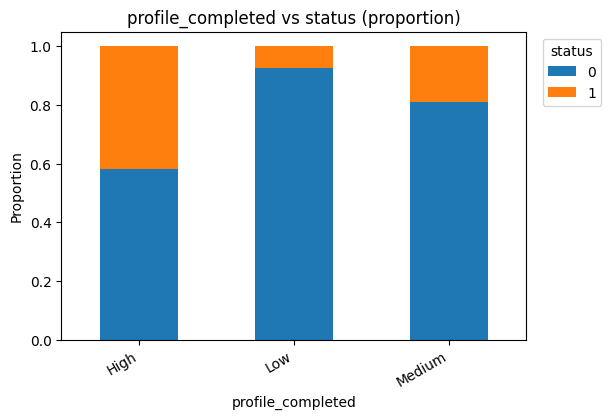

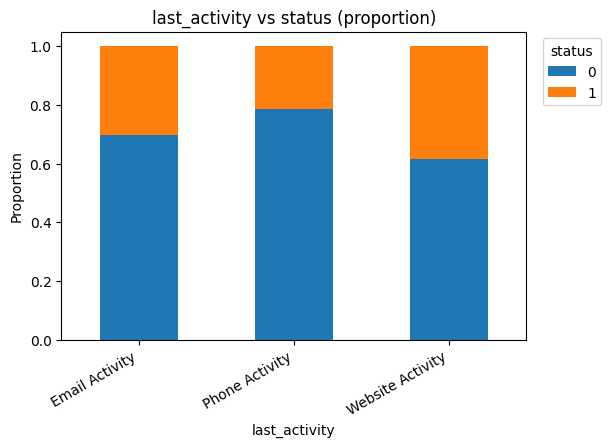

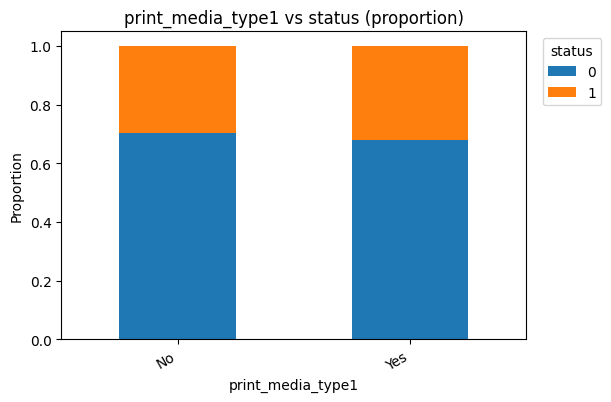

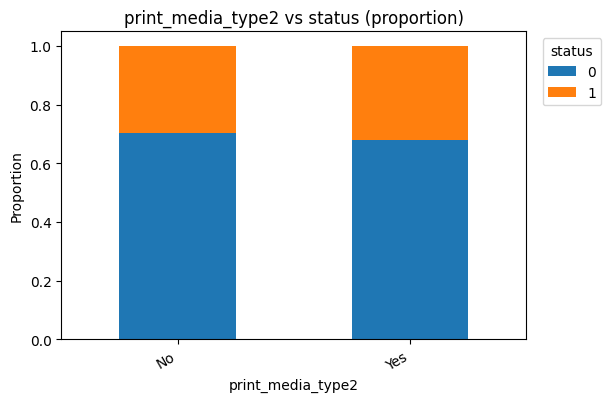

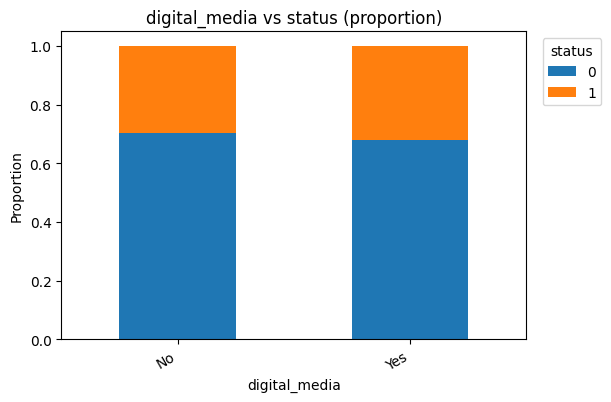

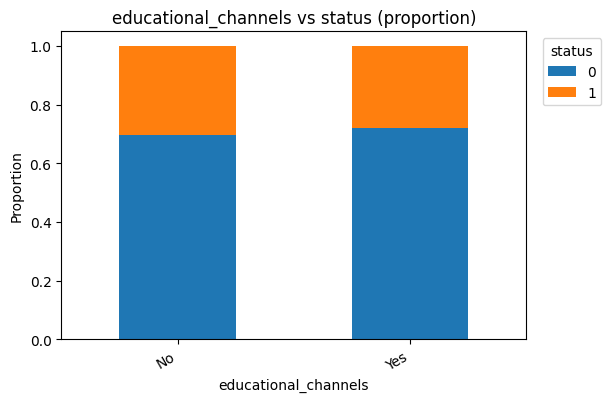

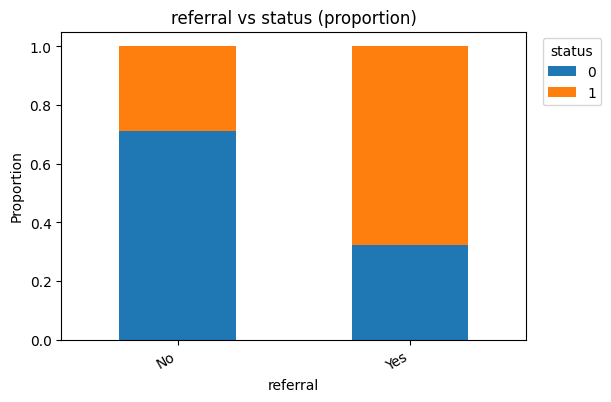

In [20]:
def stacked_barplot(data, predictor, target_col):
    """Normalized stacked bar of target within each category of predictor."""
    ct = pd.crosstab(data[predictor], data[target_col], normalize="index")
    ax = ct.plot(kind="bar", stacked=True, figsize=(6, 4))
    ax.set_title(f"{predictor} vs {target_col} (proportion)")
    ax.set_ylabel("Proportion")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title=target_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

for col in categorical_features:
    stacked_barplot(df, col, target)

### Correlation Heatmap (numeric features)

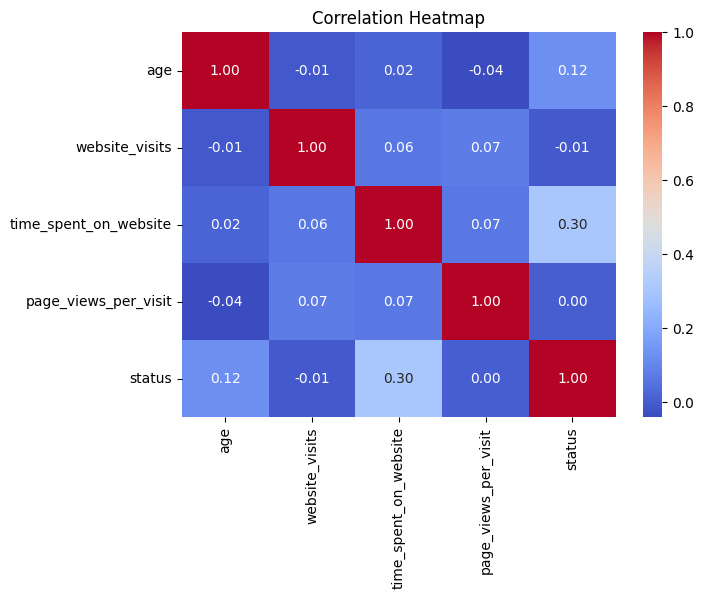

In [21]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_features + [target]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## EDA Summary (conversion rates by key categories)

In [22]:
print(f"Overall conversion rate: {df[target].mean():.2%}\n")
print("Conversion rate by current_occupation:")
print(df.groupby('current_occupation')[target].mean().sort_values(ascending=False), "\n")
print("Conversion rate by first_interaction:")
print(df.groupby('first_interaction')[target].mean().sort_values(ascending=False), "\n")
print("Conversion rate by profile_completed:")
print(df.groupby('profile_completed')[target].mean().sort_values(ascending=False), "\n")
print("Average time_spent_on_website by status:")
print(df.groupby(target)['time_spent_on_website'].mean())

Overall conversion rate: 29.86%

Conversion rate by current_occupation:
current_occupation
Professional    0.355122
Unemployed      0.265788
Student         0.117117
Name: status, dtype: float64 

Conversion rate by first_interaction:
first_interaction
Website       0.455940
Mobile App    0.105314
Name: status, dtype: float64 

Conversion rate by profile_completed:
profile_completed
High      0.417845
Medium    0.188755
Low       0.074766
Name: status, dtype: float64 

Average time_spent_on_website by status:
status
0     577.420711
1    1068.397967
Name: time_spent_on_website, dtype: float64


**Insights based on EDA**

- Leads whose **first interaction was via the Website** convert at a much higher rate than **Mobile App** leads.
- **High profile completion** is strongly associated with conversion.
- **Converted leads spend noticeably more time on the website.**
- **Professionals** convert at a higher rate than Students / Unemployed leads.
- Broad marketing flags (print/digital/educational channels, referral) individually have a weaker association with conversion.


# Data Preprocessing

**Feature engineering:** The dataset is already well-structured. The only non-informative column, `ID`, has been dropped. Tree/ensemble models capture the non-linear interactions among the existing attributes well, so no additional engineered features are needed to build a strong baseline.

**Outlier detection & treatment:** The numeric engagement features are right-skewed with genuine high-value observations (highly engaged leads). Since the final models are **tree-based / ensemble methods that are robust to outliers** (splits depend on ordering, not magnitude), outliers are **retained** rather than capped/removed, to preserve real signal. The cell below quantifies them for transparency.


In [23]:
# Outlier count via the 1.5 * IQR rule (for transparency; not treated)
for col in numeric_features:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_out} outliers by 1.5*IQR rule (retained; tree models are robust)")

age: 0 outliers by 1.5*IQR rule (retained; tree models are robust)
website_visits: 154 outliers by 1.5*IQR rule (retained; tree models are robust)
time_spent_on_website: 0 outliers by 1.5*IQR rule (retained; tree models are robust)
page_views_per_visit: 257 outliers by 1.5*IQR rule (retained; tree models are robust)


In [24]:
# Define predictors (X) and target (y)
X = df.drop(columns=[target])
y = df[target]

In [25]:
# Split into train and test sets (stratified to preserve the ~30% conversion rate)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)
print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")
print(f"Train conversion rate: {y_train.mean():.2%}, Test conversion rate: {y_test.mean():.2%}")

Training set shape: (3689, 13), Test set shape: (923, 13)
Train conversion rate: 29.85%, Test conversion rate: 29.90%


## Preprocessing Pipeline (encoding categorical features)

- **Numeric features** -> `StandardScaler`
- **Categorical features** -> `OneHotEncoder(handle_unknown='ignore')` so unseen categories at serving time don't break predictions.


In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'website_visits',
                                  'time_spent_on_website',
                                  'page_views_per_visit']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['current_occupation', 'first_interaction',
                                  'profile_completed', 'last_activity',
                                  'print_media_type1', 'print_media_type2',
                                  'digital_media', 'educational_channels',
                                  'referral'])])

# Model Building

## Metric of Choice

We choose **Recall** (on the positive class, `status = 1`) as our primary metric.

**Rationale:** ExtraaLearn wants to identify leads that are likely to convert so representatives can focus their effort. A **false negative** (a would-be customer predicted as *won't convert*) is the costly error — a **lost sale**. A **false positive** only wastes some follow-up effort. Hence we prioritise **Recall** (minimize false negatives) while monitoring precision/F1 so the model remains practically useful.


In [27]:
def model_performance_classification(model, predictors, target_values):
    """Compute accuracy, recall, precision, and F1 for a classification model."""
    pred = model.predict(predictors)
    return pd.DataFrame(
        {
            "Accuracy": accuracy_score(target_values, pred),
            "Recall": recall_score(target_values, pred),
            "Precision": precision_score(target_values, pred),
            "F1": f1_score(target_values, pred),
        },
        index=[0],
    )

## Building Models as Pipelines

The rubric requires building at least **two** models from {Decision Tree, Bagging, Random Forest, AdaBoost, Gradient Boosting, XGBoost}. We build a set of candidates as pipelines (preprocessing + estimator) and compare them, then tune the two most representative ones.


In [28]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "Bagging": BaggingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
}

pipelines = {
    name: Pipeline(steps=[("preprocessor", preprocessor), ("classifier", est)])
    for name, est in models.items()
}
pipelines["Random Forest"]

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'website_visits',
                                                   'time_spent_on_website',
                                                   'page_views_per_visit']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['current_occupation',
                                                   'first_interaction',
                                                   'profile_completed',
                                                   'last_activity',
                                                   'print_media_type1',
                                                   'print_media_type2',
                                                   'digital_media',
                                                   'educational_channels',
                                                   'referral'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [29]:
# Fit each pipeline and evaluate on train and test sets
baseline_rows = []
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    train_perf = model_performance_classification(pipe, X_train, y_train)
    test_perf = model_performance_classification(pipe, X_test, y_test)
    baseline_rows.append({
        "Model": name,
        "Train Recall": train_perf["Recall"][0],
        "Test Recall": test_perf["Recall"][0],
        "Test Accuracy": test_perf["Accuracy"][0],
        "Test Precision": test_perf["Precision"][0],
        "Test F1": test_perf["F1"][0],
    })

baseline_df = pd.DataFrame(baseline_rows).sort_values("Test Recall", ascending=False).reset_index(drop=True)
baseline_df

,Model,Train Recall,Test Recall,Test Accuracy,Test Precision,Test F1
0,Gradient Boosting,0.774750,0.753623,0.868906,0.796935,0.774674
1,Random Forest,1.000000,0.735507,0.862405,0.789883,0.761726
2,XGBoost,0.987284,0.706522,0.842904,0.752896,0.728972
3,AdaBoost,0.675749,0.692029,0.832069,0.731801,0.711359
4,Decision Tree,1.000000,0.677536,0.798483,0.658451,0.667857
5,Bagging,0.970936,0.670290,0.836403,0.755102,0.710173


**Comment on model performance:**

- The single **Decision Tree** tends to **overfit** (very high train recall, lower test recall).
- **Ensemble methods** (Random Forest, Gradient Boosting, AdaBoost, XGBoost) generalize better on the test set.
- Overall recall is moderate at default settings, so we perform hyperparameter tuning (including `class_weight='balanced'`) to boost recall on the converting class.


# Model Performance Improvement - Hyperparameter Tuning

We tune **two** models (as required by the rubric): an interpretable **Decision Tree** and a robust **Random Forest**. `GridSearchCV` optimizes for **Recall**, our metric of choice.

## 1) Decision Tree Tuning

In [30]:
dt_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

dt_param_grid = {
    "classifier__max_depth": [3, 4, 5, 6, 8, None],
    "classifier__min_samples_leaf": [1, 5, 10, 20],
    "classifier__criterion": ["gini", "entropy"],
    "classifier__class_weight": [None, "balanced"],
}

dt_grid = GridSearchCV(dt_pipe, dt_param_grid, cv=5, scoring="recall", n_jobs=-1, verbose=1)
dt_grid.fit(X_train, y_train)

print(f"Best parameters (Decision Tree): {dt_grid.best_params_}")
tuned_dt = dt_grid.best_estimator_

Fitting 5 folds for each of 96 candidates, totalling 480 fits


Best parameters (Decision Tree): {'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1}


## 2) Random Forest Tuning

In [31]:
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE)),
])

rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 8, None],
    "classifier__min_samples_leaf": [1, 5, 10],
    "classifier__max_features": ["sqrt", "log2"],
    "classifier__class_weight": [None, "balanced"],
}

rf_grid = GridSearchCV(rf_pipe, rf_param_grid, cv=5, scoring="recall", n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print(f"Best parameters (Random Forest): {rf_grid.best_params_}")
tuned_rf = rf_grid.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits


Best parameters (Random Forest): {'classifier__class_weight': 'balanced', 'classifier__max_depth': 8, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 100}


In [32]:
# Performance of the tuned models
tuned_models = {"Tuned Decision Tree": tuned_dt, "Tuned Random Forest": tuned_rf}

tuned_rows = []
for name, model in tuned_models.items():
    train_perf = model_performance_classification(model, X_train, y_train)
    test_perf = model_performance_classification(model, X_test, y_test)
    tuned_rows.append({
        "Model": name,
        "Train Recall": train_perf["Recall"][0],
        "Test Recall": test_perf["Recall"][0],
        "Test Accuracy": test_perf["Accuracy"][0],
        "Test Precision": test_perf["Precision"][0],
        "Test F1": test_perf["F1"][0],
    })

tuned_df = pd.DataFrame(tuned_rows)
tuned_df

,Model,Train Recall,Test Recall,Test Accuracy,Test Precision,Test F1
0,Tuned Decision Tree,0.905540,0.884058,0.791983,0.603960,0.717647
1,Tuned Random Forest,0.872843,0.840580,0.851571,0.713846,0.772047


**Comment on tuned models:** Using `class_weight='balanced'` and shallower trees lifts **recall** on the converting class substantially versus the untuned models, at a modest cost to precision — the right trade-off given our metric of choice.

# Model Performance Comparison, Final Model Selection, and Serialization

In [33]:
# Compare tuned models and pick the best by Test Recall
comparison_df = tuned_df.sort_values("Test Recall", ascending=False).reset_index(drop=True)
print("Model Performance Comparison (tuned models):")
comparison_df

Model Performance Comparison (tuned models):


,Model,Train Recall,Test Recall,Test Accuracy,Test Precision,Test F1
0,Tuned Decision Tree,0.905540,0.884058,0.791983,0.603960,0.717647
1,Tuned Random Forest,0.872843,0.840580,0.851571,0.713846,0.772047


In [34]:
# Select the best model by Test Recall (our metric of choice)
best_model_name = comparison_df.iloc[0]["Model"]
final_model = tuned_models[best_model_name]
print(f"Selected best model: {best_model_name}")

Selected best model: Tuned Decision Tree


**Rationale for final model:** We select the model with the **highest recall** on the unseen test set — it catches the most would-be customers — while keeping precision/F1 at a practically useful level.

In [35]:
# Performance of the final model on the test set
final_test_perf = model_performance_classification(final_model, X_test, y_test)
final_test_perf

,Accuracy,Recall,Precision,F1
0,0.791983,0.884058,0.60396,0.717647


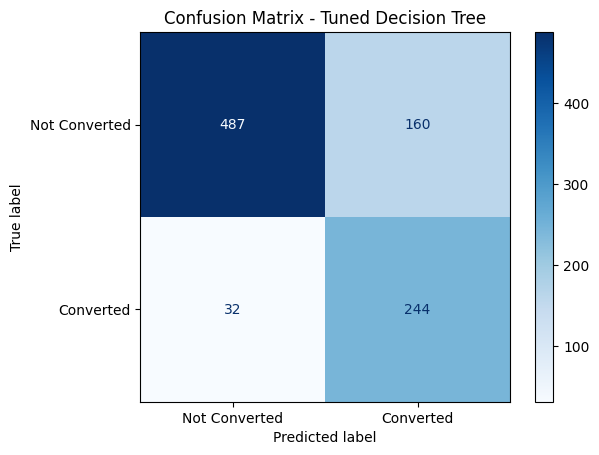

In [36]:
# Confusion matrix of the final model on the test set
cm = confusion_matrix(y_test, final_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Converted", "Converted"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## Factors Driving Lead Conversion (Feature Importance)

Top 15 features driving lead conversion:
time_spent_on_website             0.351268
first_interaction_Website         0.312054
profile_completed_Medium          0.238260
last_activity_Phone Activity      0.053060
last_activity_Website Activity    0.029283
age                               0.016075
print_media_type1_No              0.000000
referral_No                       0.000000
educational_channels_Yes          0.000000
educational_channels_No           0.000000
digital_media_Yes                 0.000000
digital_media_No                  0.000000
print_media_type2_Yes             0.000000
print_media_type2_No              0.000000
print_media_type1_Yes             0.000000
dtype: float64


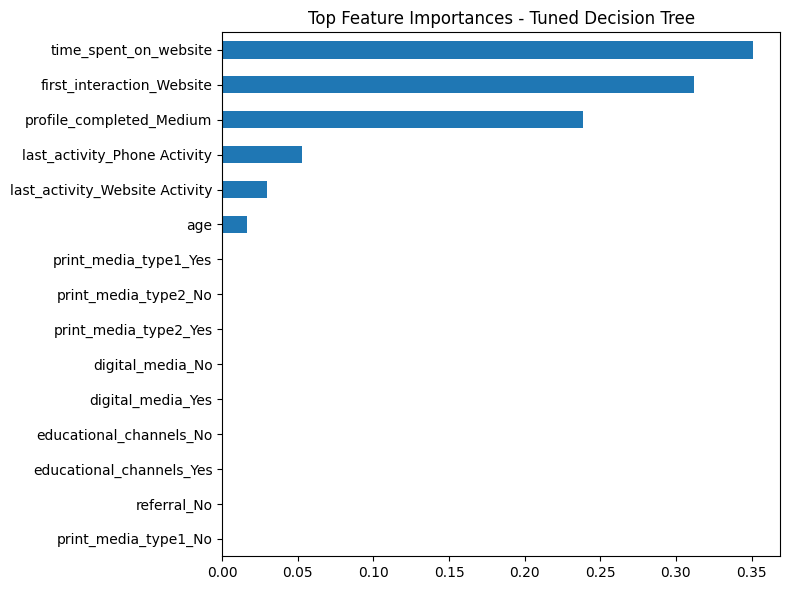

In [37]:
ohe = final_model.named_steps["preprocessor"].named_transformers_["cat"]
ohe_names = ohe.get_feature_names_out(categorical_features).tolist()
feature_names = numeric_features + ohe_names
importances = final_model.named_steps["classifier"].feature_importances_

fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print("Top 15 features driving lead conversion:")
print(fi.head(15))

plt.figure(figsize=(8, 6))
fi.head(15).sort_values().plot(kind="barh")
plt.title(f"Top Feature Importances - {best_model_name}")
plt.tight_layout()
plt.show()

## Model Serialization

In [38]:
# Create a folder for the files needed for web app deployment
os.makedirs("deployment_files", exist_ok=True)

# Serialize the final pipeline (preprocessing + model) with joblib
saved_model_path = "deployment_files/extraalearn_lead_conversion_model_v1_0.joblib"
joblib.dump(final_model, saved_model_path)
print(f"Final model serialized to: {saved_model_path}")

Final model serialized to: deployment_files/extraalearn_lead_conversion_model_v1_0.joblib


In [39]:
# Load the serialized model back and make predictions on the test set
loaded_model = joblib.load(saved_model_path)
y_pred_loaded = loaded_model.predict(X_test)
print("First 20 predictions from the reloaded model:")
print(y_pred_loaded[:20])
print(f"\nReloaded-model recall on test set: {recall_score(y_test, y_pred_loaded):.4f}")
print("The model can be used directly for predictions without retraining -> ready for deployment.")

First 20 predictions from the reloaded model:
[1 0 1 1 1 1 0 1 0 1 0 1 0 0 0 0 1 0 1 1]

Reloaded-model recall on test set: 0.8841
The model can be used directly for predictions without retraining -> ready for deployment.


# Deployment - Backend (Flask API)

We define a Flask REST API that loads the serialized model and serves predictions.


In [40]:
%%writefile deployment_files/api.py
import joblib
import pandas as pd
from flask import Flask, request, jsonify

app = Flask(__name__)

# Load the trained pipeline (preprocessing + model) once at startup.
model = joblib.load("extraalearn_lead_conversion_model_v1_0.joblib")

FEATURES = [
    "age", "current_occupation", "first_interaction", "profile_completed",
    "website_visits", "time_spent_on_website", "page_views_per_visit",
    "last_activity", "print_media_type1", "print_media_type2",
    "digital_media", "educational_channels", "referral",
]


@app.route("/", methods=["GET"])
def home():
    return jsonify({"message": "ExtraaLearn Lead Conversion API is running."})


@app.route("/predict", methods=["POST"])
def predict():
    """Accept a JSON body with lead features and return the prediction(s)."""
    payload = request.get_json(force=True)
    records = payload if isinstance(payload, list) else [payload]
    input_df = pd.DataFrame(records)[FEATURES]
    preds = model.predict(input_df).tolist()
    proba = model.predict_proba(input_df)[:, 1].tolist()
    results = [
        {"prediction": int(p), "conversion_probability": round(pr, 4)}
        for p, pr in zip(preds, proba)
    ]
    return jsonify(results if isinstance(payload, list) else results[0])


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)

Writing deployment_files/api.py


## Dependencies file (backend)

In [41]:
%%writefile deployment_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
flask==3.0.3
gunicorn==22.0.0
streamlit==1.43.2

Writing deployment_files/requirements.txt


## Dockerfile (backend)

Containerizing the app makes it portable and eliminates dependency/configuration mismatches across environments.


In [42]:
%%writefile deployment_files/Dockerfile_backend
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the build context to the container's /app
COPY . .

# Install Python dependencies
RUN pip3 install --no-cache-dir -r requirements.txt

# Expose the Hugging Face Spaces default port
EXPOSE 5000

# Serve the Flask API with gunicorn
CMD ["gunicorn", "--bind", "0.0.0.0:5000", "api:app"]

Writing deployment_files/Dockerfile_backend


## Dev Container Configuration (`.devcontainer/devcontainer.json`)

The dev container tells GitHub Codespaces how to build the environment and which ports to forward, so the app runs reliably and consistently regardless of the host machine — the same portability goal that motivated containerized deployment.

In [43]:
import os, json

os.makedirs("deployment_files/.devcontainer", exist_ok=True)

devcontainer = {
    "name": "ExtraaLearn Lead Conversion",
    "image": "mcr.microsoft.com/devcontainers/python:3.11",
    "postCreateCommand": "pip install -r requirements.txt",
    "forwardPorts": [5000, 8501],
    "portsAttributes": {
        "5000": {"label": "Flask API"},
        "8501": {"label": "Streamlit", "onAutoForward": "openBrowser"},
    },
}

with open("deployment_files/.devcontainer/devcontainer.json", "w") as f:
    json.dump(devcontainer, f, indent=2)

print("Wrote deployment_files/.devcontainer/devcontainer.json")

Wrote deployment_files/.devcontainer/devcontainer.json


## Deploy the Backend with GitHub Codespaces

Instead of Hugging Face Spaces, we host the app in a **GitHub Codespace** — a cloud dev environment that runs the code (or the container) and exposes a shareable **forwarded-port URL**.

**Steps**

1. Create a new GitHub repository and push the contents of `deployment_files/` to it (the model, `api.py`, `app.py`, `requirements.txt`, the `Dockerfile`s, and the `.devcontainer/devcontainer.json` created below).

   ```bash
   cd deployment_files
   git init && git add . && git commit -m "ExtraaLearn lead conversion app"
   git branch -M main
   git remote add origin https://github.com/praveenkmsharma-commits/ExtraaLearn.git
   git push -u origin main
   ```

2. On GitHub, click **Code → Codespaces → Create codespace on main**. The dev container installs the dependencies automatically (`pip install -r requirements.txt`).

3. In the Codespace terminal, start the API:

   ```bash
   python api.py        # or: gunicorn --bind 0.0.0.0:5000 api:app
   ```

4. Open the **Ports** tab, set port **5000** visibility to **Public**, and copy the forwarded URL. Test it:

   ```bash
   curl -X POST <forwarded-url>/predict -H "Content-Type: application/json" \
     -d '{"age":45,"current_occupation":"Professional","first_interaction":"Website","profile_completed":"High","website_visits":6,"time_spent_on_website":1200,"page_views_per_visit":3.5,"last_activity":"Website Activity","print_media_type1":"No","print_media_type2":"No","digital_media":"Yes","educational_channels":"No","referral":"No"}'
   ```

**Backend Codespaces URL:** `https://<your-codespace>-5000.app.github.dev`  *(replace with your actual forwarded URL)*

# Deployment - Frontend (Streamlit Web App)

We define a Streamlit app that provides a UI, loads the serialized model, takes user input, and displays the prediction.


In [44]:
%%writefile deployment_files/app.py
import streamlit as st
import pandas as pd
import joblib


@st.cache_resource
def load_model():
    return joblib.load("extraalearn_lead_conversion_model_v1_0.joblib")


model = load_model()

st.title("ExtraaLearn - Lead Conversion Prediction")
st.write(
    "Predict whether a lead is likely to convert to a paid customer. "
    "Fill in the lead details below and click **Predict**."
)

age = st.slider("Age", 18, 65, 35, 1)
current_occupation = st.selectbox("Current occupation", ["Professional", "Unemployed", "Student"])
first_interaction = st.selectbox("First interaction", ["Website", "Mobile App"])
profile_completed = st.selectbox("Profile completed", ["Low", "Medium", "High"])
website_visits = st.slider("Website visits", 0, 30, 3, 1)
time_spent_on_website = st.slider("Time spent on website (seconds)", 0, 3000, 300, 10)
page_views_per_visit = st.slider("Page views per visit", 0.0, 20.0, 3.0, 0.1)
last_activity = st.selectbox("Last activity", ["Email Activity", "Phone Activity", "Website Activity"])
print_media_type1 = st.selectbox("Saw Newspaper ad (print_media_type1)", ["Yes", "No"])
print_media_type2 = st.selectbox("Saw Magazine ad (print_media_type2)", ["Yes", "No"])
digital_media = st.selectbox("Saw digital media ad", ["Yes", "No"])
educational_channels = st.selectbox("Heard via educational channels", ["Yes", "No"])
referral = st.selectbox("Came through referral", ["Yes", "No"])

input_data = pd.DataFrame([{
    "age": age,
    "current_occupation": current_occupation,
    "first_interaction": first_interaction,
    "profile_completed": profile_completed,
    "website_visits": website_visits,
    "time_spent_on_website": time_spent_on_website,
    "page_views_per_visit": page_views_per_visit,
    "last_activity": last_activity,
    "print_media_type1": print_media_type1,
    "print_media_type2": print_media_type2,
    "digital_media": digital_media,
    "educational_channels": educational_channels,
    "referral": referral,
}])

if st.button("Predict"):
    pred = model.predict(input_data)[0]
    proba = model.predict_proba(input_data)[0, 1]
    if pred == 1:
        st.success(f"Lead is LIKELY to convert. (probability = {proba:.2%})")
    else:
        st.info(f"Lead is UNLIKELY to convert. (probability = {proba:.2%})")

Writing deployment_files/app.py


## Dockerfile (frontend)

In [45]:
%%writefile deployment_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the build context to the container's /app
COPY . .

# Install Python dependencies
RUN pip3 install --no-cache-dir -r requirements.txt

# Expose the Hugging Face Spaces default port
EXPOSE 8501

# Run the Streamlit frontend
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Writing deployment_files/Dockerfile


## Deploy the Frontend with GitHub Codespaces

The same repository / Codespace also serves the Streamlit UI.

1. In the Codespace terminal, run:

   ```bash
   streamlit run app.py --server.port=8501 --server.address=0.0.0.0
   ```

2. Open the **Ports** tab, set port **8501** visibility to **Public**, and open / share the forwarded URL.

Alternatively, run it as a container (uses the `Dockerfile`):

   ```bash
   docker build -t extraalearn-app .
   docker run -p 8501:8501 extraalearn-app
   ```

**Frontend Codespaces URL:** `https://<your-codespace>-8501.app.github.dev`  *(replace with your actual forwarded URL)*

The files created in `deployment_files/` for deployment (pushed to your GitHub repo) are:

- **`extraalearn_lead_conversion_model_v1_0.joblib`** – Serialized trained pipeline.
- **`api.py`** – Flask REST API (backend).
- **`app.py`** – Streamlit web app (frontend).
- **`requirements.txt`** – Python dependencies.
- **`Dockerfile`** (frontend) / **`Dockerfile_backend`** (backend) – container definitions.
- **`.devcontainer/devcontainer.json`** – GitHub Codespaces dev-container config (auto-installs deps, forwards ports 5000 & 8501).

# Actionable Insights and Business Recommendations

## Insights from the Analysis

1. **`time_spent_on_website`** is the single strongest signal — engaged leads who spend more time on the site convert far more often.
2. **`first_interaction = 'Website'`** converts much more than **'Mobile App'**.
3. **`profile_completed = 'High'`** is strongly associated with conversion.
4. **`current_occupation = 'Professional'`** leads convert at a higher rate than Students / Unemployed.
5. **`age`** contributes moderately; older professional leads skew toward converting.
6. Broad marketing flags (print/digital/educational channels, referral) have comparatively weak individual influence on conversion.

**Profile of a lead likely to convert:** A working **Professional** who first engaged via the **Website**, has a **High** profile completion, and spends a relatively **long time** browsing the site.


## Actionable Business Recommendations

- **Prioritise representative follow-up** on leads with high website time, completed profiles, and website-first interactions. Use the model to **rank daily leads by conversion probability** and route effort efficiently.
- **Improve the Mobile App experience** (or funnel app users to the website) to close the conversion gap between channels.
- **Nudge leads to complete their profiles** (progress bars, incentives), since profile completion tracks strongly with conversion.
- **Rebalance marketing spend** away from low-impact broad channels toward on-site engagement and website acquisition.
- **Deploy the serialized model** behind the Flask API / Streamlit app (containerized with Docker on Hugging Face) so agents get **real-time, consistent, low-latency** conversion scores across all offices.


<center><font size=5 color="blue">Power Ahead!</font></center>

___
